# What is LLM Distillation?

LLM Distillation is a specialized form of Knowledge Distillation (KD) that compresses large-scale LLMs into smaller, faster and more efficient models while preserving most of the performance. It enables lightweight models to approximate the capabilities of massive LLMs making them deployable on a broader range of applications and devices. Let's see a few key terms in LLM Distillation:

* Knowledge Transfer: Transferring learned knowledge from a large teacher model to a smaller student model.
* Teacher Model: A large, pretrained LLM that guides the student model during distillation.
* Student Model: A smaller, more efficient model trained to mimic the teacher’s outputs.
* Soft Labels: Probability distributions from the teacher used instead of hard class labels, conveying richer information.
* KL Divergence: A loss function measuring the difference between teacher and student output distributions.
* Inference Efficiency: Distilled models require less computation, enabling faster predictions with lower latency.
* Feature Matching: Aligning internal representations between teacher and student beyond just output logics.

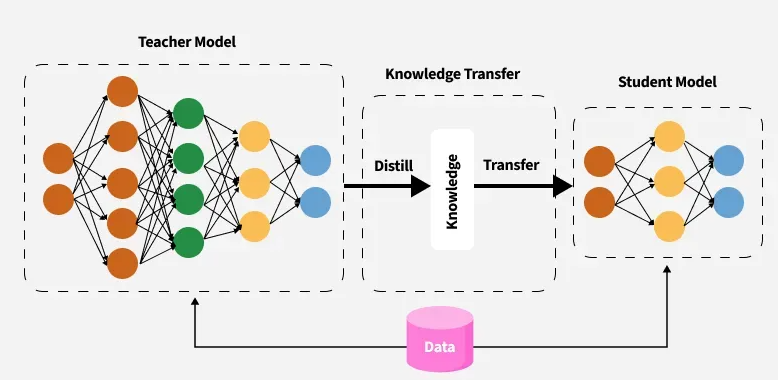

# Import Libraries
We will import the necessary modules and libraries for our model,

* torch: The main PyTorch library for tensor operations and autograd.
* torch.nn as nn: Provides neural network building blocks including layer types and modules.
* torch.optim as optim: Contains optimization algorithms like Adam used for training.
* torch.nn.functional as F: Contains functions like activation and loss functions used in forward passes.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Define the Teacher Model Class
Now we will define the Teacher model class,

class TeacherModel(nn.Module): Defines a new neural network model inheriting from nn.Module (base class for all models).
* init: The constructor method which initializes the layers.
* super(): Calls parent class’s constructor to initialize internal machinery.
* nn.Linear(input_dim, output_dim): Defines fully connected (dense) linear layers.
* forward(self, x): Defines how input x flows sequentially through layers during the forward pass.
* F.relu(): Applies the ReLU activation function to introduce non-linearity.

In [2]:
class TeacherModel(nn.Module):
    def __init__(self):
        super(TeacherModel, self).__init__()
        self.fc1 = nn.Linear(10, 50)
        self.fc2 = nn.Linear(50, 20)
        self.fc3 = nn.Linear(20, 5)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

# Define the Student Model Class
Now we will define the Student Model class which is similar to the teacher but with fewer neurons and layers (smaller model). This reflects the distilled, compressed model architecture.

In [3]:
class StudentModel(nn.Module):
    def __init__(self):
        super(StudentModel, self).__init__()
        self.fc1 = nn.Linear(10, 25)
        self.fc2 = nn.Linear(25, 5)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return self.fc2(x)

# Define Distillation Loss Function
We will define the distillation loss function using the Kullback-Leibler divergence,

* distillation_loss: Custom loss function to transfer knowledge from teacher to student.
* temperature: Smooths the output probability distribution; higher = softer probabilities.
* F.softmax(logits / temperature, dim=1): Converts logits to probability distribution along classes (dim=1).
* F.log_softmax: Log of softmax for numerical stability in KL divergence.
* F.kl_div(): Computes the Kullback-Leibler divergence (measure of difference between two distributions).
* reduction='batchmean': Averages loss across batch.
* The loss is scaled by temperature squared to maintain gradient scale.

In [4]:
def distillation_loss(student_logits, teacher_logits, temperature=2.0):
    soft_teacher_probs = F.softmax(teacher_logits / temperature, dim=1)
    soft_student_log_probs = F.log_softmax(student_logits / temperature, dim=1)
    loss = F.kl_div(soft_student_log_probs, soft_teacher_probs,
                    reduction='batchmean') * (temperature ** 2)
    return loss

# Define the Training Loop
We define the training loop for the student model,

* teacher.eval(): Disables training-specific behaviors for the teacher model.
* student.train(): Enables training-specific behaviors (dropout etc) in student.
* optimizer.zero_grad(): Resets gradients before backpropagation.
* torch.no_grad(): Temporarily disables gradient calculation to save memory when running teacher.
* loss.backward(): Backpropagation to compute gradients of student’s parameters.
* optimizer.step(): Applies parameter update using gradients.

In [5]:
def train_student(student, teacher, data, optimizer, epochs=10, temperature=2.0):
    teacher.eval()
    for epoch in range(epochs):
        student.train()
        optimizer.zero_grad()
        inputs = data
        with torch.no_grad():
            teacher_logits = teacher(inputs)
        student_logits = student(inputs)
        loss = distillation_loss(student_logits, teacher_logits, temperature)
        loss.backward()
        optimizer.step()
        print(f"Epoch {epoch + 1}, Loss: {loss.item():.4f}")

# Define Evaluation
We define the evaluation to compare the teacher and student prediction,

* Sets both models to evaluation mode.
* Runs inference without gradients.
* Uses torch.argmax to get predicted class indices (max logit).
* Calculates percentage of predictions where student agrees with teacher.

In [6]:
def evaluate_models(student, teacher, data):
    student.eval()
    teacher.eval()
    with torch.no_grad():
        teacher_preds = torch.argmax(teacher(data), dim=1)
        student_preds = torch.argmax(student(data), dim=1)
        agreement = (teacher_preds == student_preds).float().mean()
        print(
            f"Agreement between teacher and student predictions: {agreement.item() * 100:.2f}%")

# Create Synthetic training and Testing Data and Initialize Model Instances
* Uses torch.randn() to generate random float tensors as example input features.
* Instantiates the custom defined models as objects.

In [7]:
train_data = torch.randn(128, 10) #  generate random float tensors 
test_data = torch.randn(64, 10)  #  generate random float tensors 

teacher = TeacherModel()
student = StudentModel()

# Prepare for Training and Setup Optimizer for Student and Evaluate before Training
We prepare for training,

* Defines the Adam optimizer to update only the student model’s weights with a learning rate of 0.001.
* Evaluates the initial agreement between teacher and untrained student on the test data to get a baseline.

In [8]:
for param in teacher.parameters():
    param.requires_grad = False

optimizer = optim.Adam(student.parameters(), lr=0.001)

print("Before training:")
evaluate_models(student, teacher, test_data)

Before training:
Agreement between teacher and student predictions: 0.00%


# Train the Model with Knowledge Distillation and Evaluate after Training
We train the model:

* Trains the student model for 20 epochs to mimic the teacher’s softened output distributions using the distillation loss.
* Temperature smooths the teacher outputs to help student learn better soft targets.
* Measures the final prediction agreement between teacher and student on test data after training.
* The increase in agreement shows successful knowledge transfer.

In [9]:
train_student(student, teacher, train_data,
              optimizer, epochs=20, temperature=2.0)

print("\nAfter training:")
evaluate_models(student, teacher, test_data)

Epoch 1, Loss: 0.0741
Epoch 2, Loss: 0.0711
Epoch 3, Loss: 0.0683
Epoch 4, Loss: 0.0656
Epoch 5, Loss: 0.0629
Epoch 6, Loss: 0.0603
Epoch 7, Loss: 0.0578
Epoch 8, Loss: 0.0554
Epoch 9, Loss: 0.0531
Epoch 10, Loss: 0.0508
Epoch 11, Loss: 0.0487
Epoch 12, Loss: 0.0466
Epoch 13, Loss: 0.0446
Epoch 14, Loss: 0.0426
Epoch 15, Loss: 0.0408
Epoch 16, Loss: 0.0390
Epoch 17, Loss: 0.0372
Epoch 18, Loss: 0.0356
Epoch 19, Loss: 0.0340
Epoch 20, Loss: 0.0324

After training:
Agreement between teacher and student predictions: 0.00%


# Benefits of LLM Distillation
* Computational Efficiency: Smaller models require significantly less memory, computation power and storage. They enable LLMs to run on consumer hardware, mobile devices or edge computing environments.
* Reduced Latency: A distilled LLM provides faster inference times, making it more suitable for real-time applications such as chatbots and virtual assistants.
* Lower Energy Consumption: Deploying a lightweight model results in lower energy usage, which is crucial for sustainability and cost-effective AI solutions.
* Maintained Performance: Despite being smaller, a well-distilled model retains much of the accuracy and capabilities of the teacher model.
  
## Applications of LLM Distillation
* Deploying LLMs on Edge Devices: Mobile apps, IoT devices and embedded systems benefit from lightweight LLMs that maintain high accuracy.
* Optimizing Chatbots and Virtual Assistants: Virtual assistants like Siri, Google Assistant and Alexa can use distilled models for fast and efficient responses.
* Efficient Search and Recommendation Systems: Search engines and personalized recommendation models can utilize small but effective LLMs to deliver results quickly.
* Privacy-Preserving AI: Distilled models allow AI to be deployed on-device, reducing the need for cloud-based processing and improving privacy.

## Challenges in LLM Distillation
* Trade-off Between Model Size and Performance: Reducing model size too much can lead to significant performance degradation and finding the right balance is important for effective distillation.
* Knowledge Transfer Limitations: Some complex knowledge from the teacher model may be lost in the distillation process.
* Computational Costs of Distillation: The process itself is expensive because it requires training the student model on vast amounts of teacher-generated data.
* Domain-Specific Adaptation: Some tasks require domain-specific fine-tuning after distillation to ensure high accuracy.

## Future of LLM Distillation
As AI research progresses, LLM distillation will become even more crucial for real-world adoption. Some of them are:

* Neural Architecture Search (NAS): Using AI to automatically design optimal student models.
* Multi-Teacher Distillation: Combining knowledge from multiple large models for superior performance.
* Adaptive Distillation: Dynamically adjusting the complexity of the student model based on real-time computing resources.